### Notebook creado para testear las mejoras o correciones sobre CROP. solo a nivel funcional.

2025-11-20 00:28:37.619068: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 00:28:37.622842: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 00:28:37.632782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763609317.649474  110370 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763609317.654240  110370 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763609317.667452  110370 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


E0000 00:00:1763609320.217364  110370 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763609320.217950  110370 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


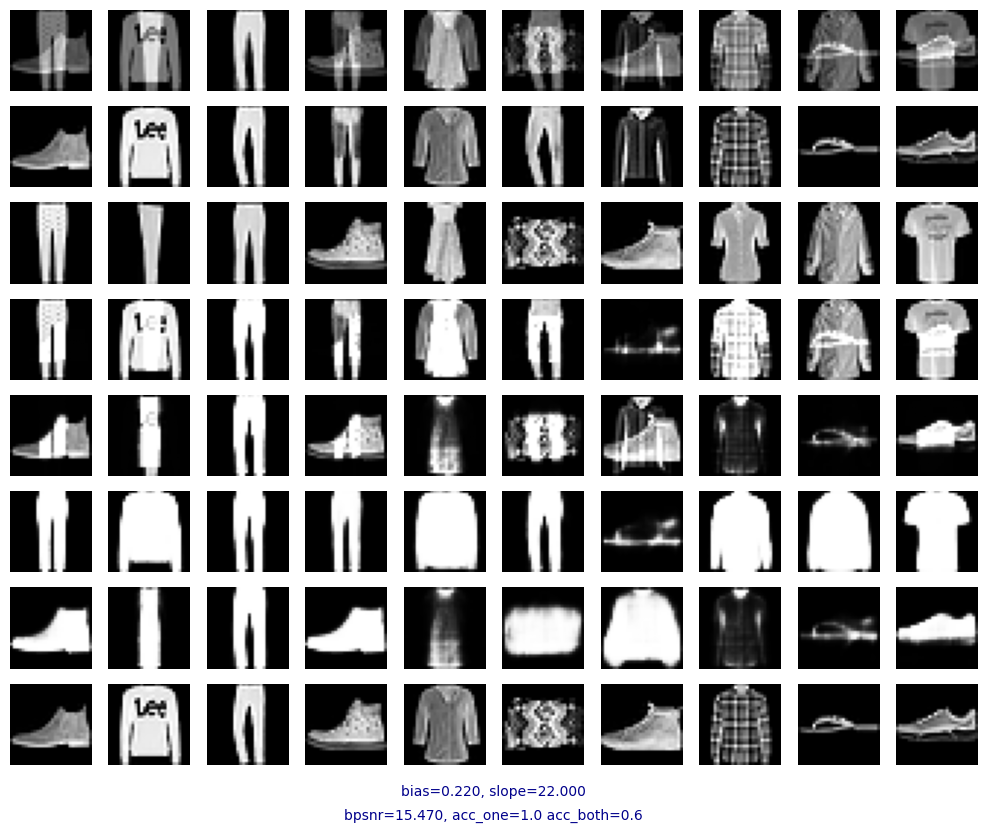

(<tf.Tensor: shape=(), dtype=float32, numpy=15.470026969909668>, <tf.Tensor: shape=(), dtype=float32, numpy=2.730886220932007>)
1.0
0.6


In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


# from CROP_models.crop2_gamma_norm import Crop2
from project.CROP.models.crop1_model import Crop1
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop_f0 = Crop1(
    model,
    predictor=predictor
)


# crop_f0 = Crop2(model,predictor=predictor,
#                data=data,bias=0.16714821597235163,slope= 17.655762570892875,beta=1)

start = 0
end = start + 10


metrics = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])